# 13 · Solid-liquid equilibria and alloy phase diagrams

How much sugar dissolves in water, at what temperature antifreeze freezes, and why an alloy of two metals
melts over a range of temperatures - and sometimes far below either metal - are all questions of
solid-liquid equilibrium. The thermodynamics is the same as for vapour-liquid equilibrium: equal chemical
potentials in both phases; the difference is that the solid's reference state involves the enthalpy of fusion.

**What you will learn**
- compute ideal and non-ideal solubilities of solids
- explain freezing-point depression and eutectics
- construct eutectic and lens (isomorphous) phase diagrams from fusion data
- connect phase diagrams to alloys and heat-transfer fluids

**Before you start:** notebooks 09-10  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, sle, unifac
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Ideal solubility
For a solid that forms an ideal solution with the liquid, the Schroeder-van Laar equation gives its mole
fraction: $\ln x = -\frac{\Delta H_{fus}}{R}\left(\frac1T - \frac1{T_m}\right)$. It depends only on the *solute's* melting point and
enthalpy of fusion - the solvent does not appear. Naphthalene ($T_m$ = 80.2 degC, $\Delta H_{fus}$ = 19.1 kJ/mol):

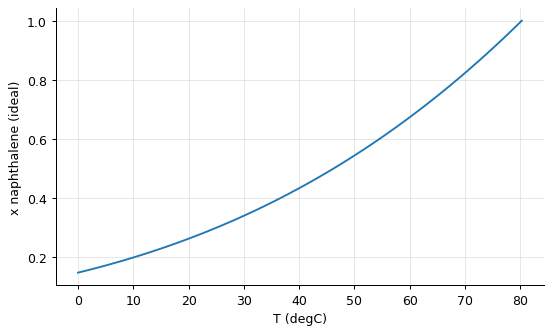

ideal solubility at 25 degC: 0.300   (experimental: in benzene 0.296, in toluene 0.286, in hexane 0.12, in water ~1e-5)


In [2]:
T = np.linspace(273.15, 353.4, 100)
plt.plot(T - 273.15, sle.ideal_solubility(T, 353.4, 19.1e3)); plt.xlabel("T (degC)"); plt.ylabel("x naphthalene (ideal)"); plt.show()
x25 = sle.ideal_solubility(298.15, 353.4, 19.1e3)
print(f"ideal solubility at 25 degC: {x25:.3f}   (experimental: in benzene 0.296, in toluene 0.286, in hexane 0.12, in water ~1e-5)")

In benzene and toluene - chemically similar to naphthalene - the ideal value is nearly exact. In hexane the
solubility is lower (positive deviations, $\gamma > 1$) and in water it is negligible: "like dissolves like" is
the activity coefficient at work. UNIFAC estimates it:

In [3]:
from scipy import optimize
for solvent in ("benzene", "n-hexane", "ethanol"):
    g = unifac.gamma_function([{"ACH": 8, "AC": 2}, solvent])            # naphthalene: 8 aromatic CH + 2 fused carbons
    f = lambda x: np.log(x * g([x, 1 - x], 298.15)[0]) + 19.1e3 / 8.314462618 * (1 / 298.15 - 1 / 353.4)
    x_sol = optimize.brentq(f, 1e-6, 0.999)
    print(f"naphthalene in {solvent:<9} at 25 degC: x = {x_sol:.3f} (gamma = {g([x_sol, 1 - x_sol], 298.15)[0]:.2f})")

naphthalene in benzene   at 25 degC: x = 0.306 (gamma = 0.98)
naphthalene in n-hexane  at 25 degC: x = 0.145 (gamma = 2.07)
naphthalene in ethanol   at 25 degC: x = 0.025 (gamma = 11.87)


## Freezing-point depression: antifreeze
Dissolving anything in water lowers its freezing point, because the solid that forms is pure ice while the
liquid's water activity is reduced. For an ideal solution the same equation, applied to *water* as the solute
crystallising as ice ($T_m$ = 273.15 K, $\Delta H_{fus}$ = 6.01 kJ/mol):

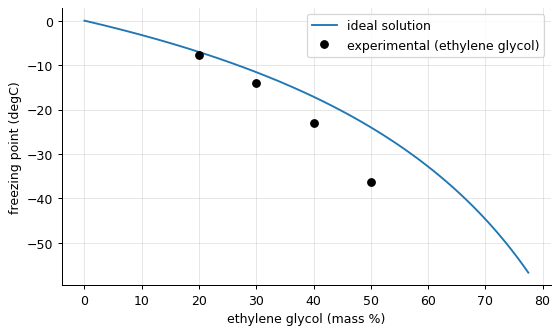

In [4]:
x_glycol = np.linspace(0, 0.5, 51)
T_freeze = [sle.liquidus_T(1 - x, 273.15, 6.01e3) for x in x_glycol]         # water mole fraction 1 - x
M_g, M_w = 62.07, 18.02
w_glycol = x_glycol * M_g / (x_glycol * M_g + (1 - x_glycol) * M_w)
plt.plot(w_glycol * 100, np.array(T_freeze) - 273.15, label="ideal solution")
plt.plot([20, 30, 40, 50], [-7.8, -14.1, -23.0, -36.4], "ko", label="experimental (ethylene glycol)")
plt.xlabel("ethylene glycol (mass %)"); plt.ylabel("freezing point (degC)"); plt.legend(); plt.show()

The ideal-solution curve captures the trend; the real antifreeze depresses the freezing point somewhat more
at high concentration (glycol-water shows moderate negative deviations). A 50 % mixture protects to about
-36 degC - the basis of every engine coolant and of the low-temperature heat-transfer fluids of solar and
geothermal systems.

## Eutectic alloys: Bi-Cd
Two metals that do not dissolve in each other's solid but mix ideally as liquids: each liquidus branch is the
ideal solubility of one metal in the melt, and they meet at the **eutectic** - the lowest melting point of the
system, where the liquid freezes into a fine mixture of both solids:

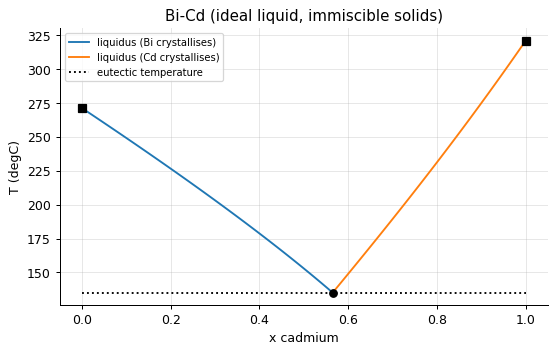

predicted eutectic: 0.57 mole fraction Cd at 135 degC; experimental: 0.55 at 140 degC


In [5]:
Tm_Bi, dH_Bi, Tm_Cd, dH_Cd = 544.5, 11.3e3, 594.2, 6.19e3
cur = sle.liquidus_curves(Tm_Bi, dH_Bi, Tm_Cd, dH_Cd)
plt.plot(1 - cur["x1_branch1"], cur["T_branch1"] - 273.15, "C0", label="liquidus (Bi crystallises)")
plt.plot(1 - cur["x1_branch2"], cur["T_branch2"] - 273.15, "C1", label="liquidus (Cd crystallises)")
Te = cur["eutectic"]["T"] - 273.15
plt.hlines(Te, 0, 1, colors="k", linestyles=":", label="eutectic temperature")
plt.plot(1 - cur["eutectic"]["x1"], Te, "ko"); plt.plot([0, 1], [Tm_Bi - 273.15, Tm_Cd - 273.15], "ks")
plt.xlabel("x cadmium"); plt.ylabel("T (degC)"); plt.title("Bi-Cd (ideal liquid, immiscible solids)"); plt.legend(fontsize=8); plt.show()
print(f"predicted eutectic: {1 - cur['eutectic']['x1']:.2f} mole fraction Cd at {Te:.0f} degC; experimental: 0.55 at 140 degC")

With only the melting points and enthalpies of fusion the eutectic is predicted within a few degrees. Low
melting eutectics are the basis of solders (Sn-Pb, Sn-Ag-Cu), of fusible alloys for safety devices, and of the
salt mixtures (e.g. NaNO$_3$-KNO$_3$) used as heat-transfer and storage media in solar thermal power plants.

## Isomorphous alloys: Cu-Ni
Copper and nickel mix completely in both liquid and solid. With ideal solutions in both phases, the
liquidus and solidus follow from the two equilibrium constants $K_i = x_i^S/x_i^L$:

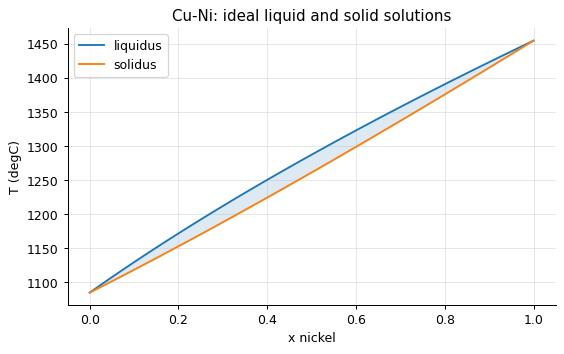

a 50/50 melt starts to freeze at 1288 degC, and the first solid contains 0.57 mole fraction Ni


In [6]:
lens = sle.lens_diagram(1358.0, 13.05e3, 1728.0, 17.47e3)
plt.plot(1 - lens["x1_liquidus"], lens["T"] - 273.15, label="liquidus"); plt.plot(1 - lens["x1_solidus"], lens["T"] - 273.15, label="solidus")
plt.fill_betweenx(lens["T"] - 273.15, 1 - lens["x1_liquidus"], 1 - lens["x1_solidus"], alpha=0.15)
plt.xlabel("x nickel"); plt.ylabel("T (degC)"); plt.title("Cu-Ni: ideal liquid and solid solutions"); plt.legend(); plt.show()
i = np.argmin(np.abs(lens["x1_liquidus"] - 0.5))
print(f"a 50/50 melt starts to freeze at {lens['T'][i]-273.15:.0f} degC, and the first solid contains {1 - lens['x1_solidus'][i]:.2f} mole fraction Ni")

The lens (or cigar) diagram: an alloy freezes over a temperature range, and the first solid is richer in the
higher-melting metal than the liquid it came from. Cast slowly, the composition of the solid changes as
freezing proceeds - the origin of *coring* and segregation in castings, which heat treatments must remove.
The same two-phase lens, with the roles of vapour and liquid, was the T-x-y diagram of notebook 08: the
thermodynamics of separation is one subject.

## Inside the algorithm: the eutectic as the intersection of two liquidus curves
Each liquidus is the temperature at which the melt is saturated with one solid; the eutectic is where both are:

In [7]:
from scipy import optimize
R_ = 8.314462618
T_liq = lambda x, Tm, dH: 1 / (1 / Tm - R_ * np.log(x) / dH)              # ideal liquidus (x = mole fraction of the crystallising metal)
x_e = optimize.brentq(lambda xBi: T_liq(xBi, Tm_Bi, dH_Bi) - T_liq(1 - xBi, Tm_Cd, dH_Cd), 1e-6, 1 - 1e-6)
print(f"by hand: x_Bi = {x_e:.4f}, T = {T_liq(x_e, Tm_Bi, dH_Bi) - 273.15:.1f} degC;  library: x_Bi = {cur['eutectic']['x1']:.4f}, {Te:.1f} degC")

by hand: x_Bi = 0.4348, T = 135.1 degC;  library: x_Bi = 0.4348, 135.1 degC


## Exercises
1. Tin (Tm 505 K, 7.03 kJ/mol) and lead (Tm 600.6 K, 4.77 kJ/mol) form the classic solder eutectic. Predict it with ideal liquids and compare with the experimental 183 degC at 0.74 mole fraction Sn. What does the discrepancy tell you about the Sn-Pb liquid?
2. Solar salt is 60/40 by mass NaNO3 (Tm 307 degC, 15.0 kJ/mol) / KNO3 (Tm 334 degC, 10.0 kJ/mol). Predict the eutectic of the ideal melt and compare with the observed 222 degC. Why does a low melting point matter for a thermal-storage medium?
3. **Implement it yourself:** compute the Cu-Ni liquidus and solidus at 1500 K from the two equilibrium constants by hand and compare with `sle.lens_diagram`.